---
title: "Mars-van Krevelen: the redox rate law, read from the paper that derived it"
description: "The 1954 origin of redox (Mars-van Krevelen) kinetics prints no rate constant for any aromatic oxidation - its printed numbers are all in the SO2 application. This page transcribes those tables at native resolution, reproduces the authors' own k' columns and their 23:77 converter catalyst split from printed inputs alone, shows their integrated rate form beats two period competitors on the data they reprinted, and proves two printed equations wrong from the paper's own neighbouring equations."
categories: [sec:C, struct:S1, tier:T0, data:tier2, phase:gas-solid]
date: 2026-08-05
---

# Mars-van Krevelen: the redox rate law, read from the paper that derived it

**Catalog ID:** `C1.3` · **Structures:** `S1` (1D steady plug flow) · **Tier:** T0

Every partial-oxidation kinetics paper that writes

$$\dot n_R=\frac{1}{\dfrac{1}{k_1\,p_R}+\dfrac{\beta}{k_2\,p_{\mathrm{O}_2}^{\,n}}}$$

cites Mars and van Krevelen (1954). This page is about what that paper actually
contains — which turns out to be different from what is usually attributed to
it — and about the one complete worked calculation it prints: the design of a
two-stage SO$_2$ converter from the redox rate law, ending in a catalyst split
the authors state as **23 : 77** against an actual plant's 27 : 73. That
calculation is reproduced here end to end from printed inputs alone, twice
(adaptive quadrature and a pymrm plug-flow solve), and every printed
intermediate on the way — two k$'$ tables, an activation energy, an equilibrium
correlation, a gas-composition table — is recomputed and reconciled.

## Background

### What the paper is

Mars, P. and van Krevelen, D. W., *Oxidations carried out by means of vanadium
oxide catalysts*, Special Supplement to Chemical Engineering Science **3**
(1954) 41–59, [doi:10.1016/S0009-2509(54)80005-4](https://doi.org/10.1016/S0009-2509(54)80005-4)
— a conference paper (Conference on Oxidation Processes) from the Staatsmijnen
in Limburg Central Laboratory, Geleen, with a printed discussion by J. M. Smith,
H. Jockush, H. A. Cheney, C. P. van Dijk, C. F. P. Bevington and G. C. A.
Schuit. Everything on this page was read from cropped renders of the 19-page
scan at its native 300 ppi (`pdfimages -list` reports CCITT-G4 bilevel at
300×300); the OCR text layer was used for nothing numeric.

The paper has three parts:

1. **Fluid-bed oxidation of aromatics** (benzene, toluene, naphthalene,
   anthracene) over V$_2$O$_5$ — a fluid bed because these oxidations are so
   exothermic that no fixed bed holds a uniform temperature. Both partial
   pressures influence the rate; the two-step redox scheme is proposed and the
   composite rate law derived (their eqs. 1–7).
2. **SO$_2$ oxidation** — the same formalism applied to three literature data
   sets (Küster 1904, Neumann 1928, Krichevskaya 1947), with the equilibrium
   term added and internal diffusion analysed (eqs. 8–16).
3. **A technical converter examined** — rate constants derived from plant data
   (their Table 3), the optimum temperature curve computed, and the catalyst
   split between the two converters calculated and compared with practice.

### What the paper prints, and what it does not

This matters, because the paper is cited far more often than read. **Every
number the paper prints is in the SO$_2$ part.** For the aromatic oxidations —
the ones the mechanism is named for — the paper prints *figures only* (its
Figs. 2–10): no table of rates, and no numeric value of $k_1$, $k_2$ or
$\beta$ for any aromatic, at any temperature. The only aromatic-side numbers in
prose are the activation energy of the re-oxidation step, **22 kcal/mol**, and
the catalyst compositions in two footnotes. Anyone quoting "the Mars–van
Krevelen constants" for benzene oxidation is quoting a later fit, not this
paper.

Two more things commonly attributed to the paper deserve care:

- **"Lattice oxygen" is a supposition here, not a demonstration.** The authors
  attribute catalytic action to "certain oxygen ions" of the V$_2$O$_5$
  structure (their Fig. 5, after Byström et al.) and support the redox picture
  with colour changes and tetravalent-vanadium analyses from the literature.
  The rate-law derivation itself needs only a surface fraction $\theta$ covered
  by oxygen; no isotope evidence exists in 1954.
- **The authors themselves disclaim mechanistic proof.** In the printed
  discussion, J. M. Smith observes that an adsorption-based three-step mechanism
  "leads to a kinetic equation similar to the one proposed", and the authors
  reply: *"Naturally, agreement between a kinetic formula and experimental data
  is not a proof of the correctness of the assumed reaction mechanism."* (The same reply continues that agreement *"may be held to support the assumed mechanism"* - the disclaimer is about proof, not support.) The
  famous rate form is kinetically indistinguishable from other two-step
  steady-state schemes, and the origin paper says so on its own last pages.

### Why the SO$_2$ part carries the page

The printed tables are real measurements — Küster's and Neumann's, reprinted
with the authors' own derived k$'$ columns beside them — and the converter
calculation is a complete worked design with printed inputs (Table 3), a
printed equilibrium correlation (eq. 8) and a printed result (23 : 77). That
is validation of the strongest kind available for a 1954 paper: printed
intermediates that can be recomputed and compared, with no figure digitised.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq, minimize_scalar
from pymrm import construct_convflux_upwind, construct_div, NumJac, newton
from gallery_utils import load_data, load_meta, cite_data, report_agreement

PAGE = "C1.3-mars-van-krevelen-redox"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

R_GAS = 8.314          # J/(mol K)
CAL = 4184.0           # J per kcal
metrics = {}           # collected for report_agreement at the end

## The published model

### The redox scheme and the composite rate law

The two reactions, exactly as formulated on journal page 46:

> I. aromatic compound + oxidized catalyst $\rightarrow$ oxidation products + reduced catalyst
> II. reduced catalyst + oxygen $\rightarrow$ oxidized catalyst

With $\theta$ the fraction of surface covered by oxygen, first order in the
aromatic and order $n$ in oxygen:

$$\dot n_R = k_1\,p_R\,\theta \tag{1}$$
$$\dot n_{\mathrm{O}_2} = k_2\,p_{\mathrm{O}_2}^{\,n}\,(1-\theta) \tag{2}$$
$$\dot n_R = \tfrac{1}{\beta}\,\dot n_{\mathrm{O}_2} \tag{3}$$

where $\beta$ is the number of O$_2$ molecules needed per molecule of aromatic
converted — determined from the measured product distribution, not fitted. The
steady state $\beta k_1 p_R \theta = k_2 p_{\mathrm{O}_2}^n (1-\theta)$ (their
eq. 4) gives eq. (5) for $\theta$ and the composite law, their boxed eq. (6):

$$\dot n_R=\frac{1}{\dfrac{1}{k_1\,p_R}+\dfrac{\beta}{k_2\,p_{\mathrm{O}_2}^{\,n}}} \tag{6}$$

— two resistances in series, reduction and re-oxidation. For the experimental
test they integrate it over the (integrating, not stirred) fluid bed for
$n = 1$, their eq. (7):

$$\frac{1}{V_s}=\frac{1}{k_1}\ln\frac{(p_R)_0}{(p_R)_{\rm final}}
 +\frac{1}{k_2}\ln\frac{(p_{\mathrm{O}_2})_0}{(p_{\mathrm{O}_2})_{\rm final}},
 \qquad (p_{\mathrm{O}_2})_{\rm final}=(p_{\mathrm{O}_2})_0-\beta\left[(p_R)_0-(p_R)_{\rm final}\right]$$

with $V_s$ the space velocity. (Checked by hand: eq. (7) is the exact integral
of eq. (6) at $n=1$ under $\mathrm{d}p_{\mathrm{O}_2} = \beta\,\mathrm{d}p_R$.)
Figures 6–8 test this against their own benzene, naphthalene and anthracene
runs — figures only, so they are outside this page's scope (see *The data*).

### The SO$_2$ chain

For SO$_2$ the product retards the rate, so a third surface reaction and its
equilibrium enter ($K^\ast$ small), and with re-oxidation rate-determining the
chain runs (journal page 50): equilibrium eq. (8),

$$K=\frac{p_{\mathrm{SO}_3}^2}{p_{\mathrm{SO}_2}^2\,p_{\mathrm{O}_2}}\ \ \text{(atm)},\qquad
{}^{10}\!\log K=\frac{9880}{T}-9.34 \tag{8}$$

through $\theta$ (eq. 10), the rate (eqs. 11–12), the high-conversion
approximation (eq. 13), its conversion form (13a)

$$\dot n_{\mathrm{SO}_2}= k\,p_{\mathrm{O}_2}^{\,n}\,
\frac{\alpha_{\rm eq}-\alpha}{\alpha\,\alpha_{\rm eq}}
=\frac{k\,p_{\mathrm{O}_2}^{\,n}}{\alpha_{\rm eq}}\,\frac{1-\alpha'}{\alpha'} ,
\qquad \alpha'=\frac{\alpha}{\alpha_{\rm eq}} \tag{13a}$$

and its integrated form (14), which is what the k$'$ columns of Tables 1 and 2
were computed with:

$$\frac{k}{V_s}\,\frac{(\bar p_{\mathrm{O}_2})^n}{(p_{\mathrm{SO}_2})_0}
=\alpha_{\rm eq}\left\{\ln\frac{1}{1-\alpha'}-\alpha'\right\} \tag{14}$$

For the technical catalyst, internal diffusion cuts in; the pore analysis gives
the diffusion-limited rate (15) and its integral (16):

$$\dot n_{\mathrm{SO}_2}\sim r_p\sqrt{k\,D\,r_p\,(\bar p_{\mathrm{O}_2})^n\,(p_{\mathrm{SO}_2})_0\,\alpha'}\;
\frac{1-\alpha'}{\alpha'} \tag{15}$$

$$\frac{k^\ast}{2}\sqrt{\frac{(p_{\mathrm{O}_2})^n}{(p_{\mathrm{SO}_2})_0}}\cdot\frac{t}{\alpha_{\rm eq}}
=\sqrt{\alpha/\alpha_{\rm eq}}-\tanh^{-1}\sqrt{\alpha/\alpha_{\rm eq}} \tag{16 as printed}$$

### Two printed equations the paper's own neighbours contradict

Both provable without leaving the paper, in the `F2.3`/`B1.2` manner — from the
paper's own results, with the alternatives printed.

**Eq. (16): the right-hand side is sign-inverted.** As printed, the RHS
$\sqrt{\alpha'}-\tanh^{-1}\sqrt{\alpha'}$ is $\le 0$ for every $\alpha'$
(since $\tanh^{-1}x \ge x$), while the LHS is a positive time. Integrating the
paper's own eq. (15) — $\alpha_{\rm eq}\,\mathrm{d}\alpha'/\mathrm{d}t \propto
(1-\alpha')/\sqrt{\alpha'}$, so $\int\!\sqrt{\alpha'}/(1-\alpha')\,
\mathrm{d}\alpha' = 2\left[\tanh^{-1}\sqrt{\alpha'}-\sqrt{\alpha'}\right]$ —
reproduces the printed LHS exactly, prefactor and $\alpha_{\rm eq}$ included,
with the two RHS terms **transposed**. The check below does the integral
numerically and scores both signs.

**Eqs. (13a) and (14) disagree by one factor of $\alpha_{\rm eq}$.** Under the
natural reading ($\dot n_{\mathrm{SO}_2}=(p_{\mathrm{SO}_2})_0\,
\mathrm{d}\alpha/\mathrm{d}t$, $t = 1/V_s$), integrating (13a) gives
$k'/V_s=\alpha_{\rm eq}^{\,2}\{\ln\frac{1}{1-\alpha'}-\alpha'\}$ — the printed
(14) carries $\alpha_{\rm eq}$ to the **first** power. One of the two carries a
typographical slip. At the conditions of Tables 1–2 the stray factor is between
1.00 and $\approx$ 0.90, comparable to the data scatter, and the k$'$
recomputation below is run **both ways** and reports both; nothing downstream
of this page depends on which the authors intended.

Also checked here: the van 't Hoff slope of eq. (8) is a reaction enthalpy the
paper states independently — "SO$_2$ + ½O$_2$ $\rightarrow$ SO$_3$ +
23 k.cal/mol" (journal page 48).

In [3]:
# --- eq (16): numeric integral of eq (15) vs the printed RHS and the corrected RHS
apv = np.array([0.3, 0.7, 0.95])
numeric  = np.array([quad(lambda x: np.sqrt(x)/(1.0 - x), 0.0, a)[0] for a in apv])
corrected = 2*(np.arctanh(np.sqrt(apv)) - np.sqrt(apv))
printed   = 2*(np.sqrt(apv) - np.arctanh(np.sqrt(apv)))
tab = pd.DataFrame({"alpha_prime": apv, "numeric integral of (15)": numeric,
                    "2[atanh(sqrt a') - sqrt a'] (corrected)": corrected,
                    "2[sqrt a' - atanh(sqrt a')] (as printed)": printed})
print(tab.to_string(index=False))
raw_resid = float(np.max(np.abs(numeric - corrected)))
# the raw residual is quadrature noise (~5e-12); floor the REPORTED metric at 1e-9 so it
# is stable across machines instead of tracking scipy's adaptive tolerance
metrics["eq16_corrected_max_residual"] = max(raw_resid, 1e-9)
metrics["eq16_printed_rhs_max_error"]  = float(np.max(np.abs(numeric - printed)))
print(f"\ncorrected RHS matches the numeric integral to {raw_resid:.2e} "
      f"(reported metric floored at 1e-9); the printed RHS is wrong by up to "
      f"{metrics['eq16_printed_rhs_max_error']:.3f} (and negative where the LHS is a positive time).")

# --- van 't Hoff slope of eq (8) vs the printed reaction heat
# K is written for 2 SO2 + O2 -> 2 SO3, so dH per mol SO3 is half the slope.
dH_kcal = R_GAS * 9880.0 * np.log(10.0) / 2.0 / CAL
metrics["vantHoff_dH_kcal_per_mol_SO3"] = dH_kcal
metrics["vantHoff_vs_printed_23"] = abs(dH_kcal / 23.0 - 1.0)
print(f"van 't Hoff slope of eq (8): dH = -{dH_kcal:.2f} kcal/mol SO3 "
      f"against the printed 23 kcal/mol -> {metrics['vantHoff_vs_printed_23']*100:.1f} % apart.")

 alpha_prime  numeric integral of (15)  2[atanh(sqrt a') - sqrt a'] (corrected)  2[sqrt a' - atanh(sqrt a')] (as printed)
        0.30                  0.134799                                 0.134799                                 -0.134799
        0.70                  0.746550                                 0.746550                                 -0.746550
        0.95                  2.407186                                 2.407186                                 -2.407186

corrected RHS matches the numeric integral to 4.78e-12 (reported metric floored at 1e-9); the printed RHS is wrong by up to 4.814 (and negative where the LHS is a positive time).
van 't Hoff slope of eq (8): dH = -22.60 kcal/mol SO3 against the printed 23 kcal/mol -> 1.7 % apart.


## Parameters and assumptions

Everything printed that this page consumes, and the three assumptions it has to
add:

| quantity | value | status |
|---|---|---|
| equilibrium correlation | $^{10}\!\log K = 9880/T - 9.34$ (atm, $T$ in K) | printed, eq. (8) |
| technical-catalyst rate group $k^\ast\sqrt{(\bar p_{\mathrm{O}_2})^n (p_{\mathrm{SO}_2})_0}$ | 164 atm/hr at 445 °C; 400 atm/hr at 570 °C | printed, Table 3 |
| oxygen order for SO$_2$ | $n = \tfrac12$ (Krichevskaya's data, Figs. 12–13; eq. 12 used with $n = 0.5$) | printed statement |
| converter targets | converter 1: 0 → 81 %; converter 2: 81 → 97 % | printed, journal page 55 |
| re-oxidation activation energy (no diffusion) | 22 kcal/mol | printed, journal page 47 |
| feed gas for the converter calculation | 8 % SO$_2$, 10.6 % O$_2$ (a printed Table 4 pair) | **assumed** — the paper does not state the plant's feed; sensitivity swept below |
| Neumann's gas composition | SO$_2$ + air, SO$_2$ fraction **fitted** | not printed anywhere |
| Neumann's velocity units | unknown; absorbed into one **fitted** scale | not printed anywhere |

**Fit versus test, declared up front.** Fitted on this page: (i) the global
scale $C$ and the SO$_2$ inlet fraction $s$ of the Neumann recomputation,
fitted **only on the 325–465 °C blocks** (19 rows); (ii) both parameters of
the Küster recomputation (6 rows — no test possible, Küster's conditions are
unprinted); (iii) one rate constant per temperature block in the
rate-law-discrimination fits; (iv) one stoichiometric coefficient in the
Table 4 gas-composition question. Everything else is a **test**: the
475–550 °C Neumann blocks (13 unbracketed rows, nothing refitted), the
activation energy against "about 9 kcal/mol", the van 't Hoff slope against
23 kcal/mol, and the catalyst split against 23 : 77 — the last with *no fitted
quantity anywhere in its chain*.

## The data

Four datasets, all transcribed from cropped renders at the scan's native
300 ppi. Tables 1 and 2 are **experimental measurements** — but not the
authors' own: they are Küster's (1904) and Neumann's (1928), reprinted by Mars
& van Krevelen with the authors' own computed k$'$ columns beside them. The
originals were not consulted (`origin_not_consulted` in the sidecars); every
value is as this paper prints it, which is exactly what a page about *this
paper's* calculation needs.

**Scoped out — everything that exists only as a figure.** The aromatic-side
kinetics (Figs. 2–3 conversion curves, Figs. 6–8 linearised fits, Fig. 9
Arrhenius, Fig. 10 Porter-catalyst comparison), Krichevskaya's SO$_2$ data
(Figs. 12–13), Calderbank's (Fig. 14), the plant temperature profile (Fig. 11)
and the optimum-temperature curve (Fig. 16) are all figure-only. No maintainer
is currently available for figure review, so no figure is digitised and no
number on this page is read from one. The cost is stated where it bites: the
famous rate law's own quantitative fit to the aromatic data is untested here
because *the paper prints no table to test it against* — the strongest
attribution finding on this page. What remains testable is everything the
paper prints as numbers, which is the whole SO$_2$ application.

In [4]:
t1 = load_data("mars-vankrevelen-1954-table1-kuster.csv", page=PAGE)
t2 = load_data("mars-vankrevelen-1954-table2-neumann.csv", page=PAGE)
t3 = load_data("mars-vankrevelen-1954-table3-converter.csv", page=PAGE)
t4 = load_data("mars-vankrevelen-1954-table4-gas.csv", page=PAGE)
for name in ["mars-vankrevelen-1954-table1-kuster", "mars-vankrevelen-1954-table2-neumann",
             "mars-vankrevelen-1954-table3-converter", "mars-vankrevelen-1954-table4-gas"]:
    print(cite_data(load_meta(name + ".csv", page=PAGE)))
print(f"\nTable 1: {len(t1)} rows   Table 2: {len(t2)} rows ({int(t2.bracketed.sum())} bracketed)   "
      f"Table 3: {len(t3)} rows   Table 4: {len(t4)} rows")

Mars, P.; van Krevelen, D. W. (1954) — Special Supplement to Chemical Engineering Science 3, 41-59 — doi:10.1016/S0009-2509(54)80005-4 — table
Mars, P.; van Krevelen, D. W. (1954) — Special Supplement to Chemical Engineering Science 3, 41-59 — doi:10.1016/S0009-2509(54)80005-4 — table
Mars, P.; van Krevelen, D. W. (1954) — Special Supplement to Chemical Engineering Science 3, 41-59 — doi:10.1016/S0009-2509(54)80005-4 — table
Mars, P.; van Krevelen, D. W. (1954) — Special Supplement to Chemical Engineering Science 3, 41-59 — doi:10.1016/S0009-2509(54)80005-4 — table

Table 1: 6 rows   Table 2: 33 rows (1 bracketed)   Table 3: 2 rows   Table 4: 7 rows


In [5]:
# --- the paper's own checksum: the printed per-block k' average column
print("k' average: mean of unbracketed printed rows vs the printed average")
worst = 0.0
for Tc, blk in t2.groupby("temperature_C"):
    ok = blk[blk.bracketed == 0]
    mean = ok.k_prime.mean()
    printed_avg = blk.k_prime_avg_printed.iloc[0]
    diff = mean - printed_avg
    worst = max(worst, abs(diff))
    flag = "  <-- paper's own arithmetic is off" if abs(diff) > 0.002 else ""
    print(f"  {Tc:3.0f} C: mean = {mean:.5f}   printed = {printed_avg:.3f}   diff = {diff:+.5f}{flag}")
metrics["kavg_checksum_worst_block"] = worst
m425 = t2[(t2.temperature_C == 425)].k_prime
print(f"\nThe 425 C block: all four rows average {m425.mean():.5f}, but the first three alone "
      f"average {m425.iloc[:3].mean():.5f} - the printed 0.315 is exactly the three-row mean, so the "
      f"paper either mis-averaged or silently dropped its 750 row.")
agree = sum(1 for Tc in sorted(t2.temperature_C.unique())
            if abs(t2[t2.temperature_C == Tc].k_prime.mean()
                   - t2[t2.temperature_C == Tc].k_prime_avg_printed.iloc[0]) < 5e-4)
nblk = t2.temperature_C.nunique()
print(f"Blocks whose printed average matches the row mean to the last printed digit: "
      f"{agree} of {nblk}. The remainder differ by rounding-chain amounts (the paper "
      f"averages pre-rounded rows), except 475 C, whose 0.00125 gap exceeds what "
      f"pre-rounding can explain - a second small unreported slip. The column still "
      f"functions as a transcription checksum: a wrong DIGIT in any row moves its "
      f"block mean by far more than these rounding residues.")

k' average: mean of unbracketed printed rows vs the printed average
  325 C: mean = 0.10733   printed = 0.107   diff = +0.00033
  375 C: mean = 0.18775   printed = 0.188   diff = -0.00025
  425 C: mean = 0.31125   printed = 0.315   diff = -0.00375  <-- paper's own arithmetic is off
  450 C: mean = 0.36625   printed = 0.366   diff = +0.00025
  465 C: mean = 0.38975   printed = 0.389   diff = +0.00075
  475 C: mean = 0.41775   printed = 0.419   diff = -0.00125
  500 C: mean = 0.43650   printed = 0.436   diff = +0.00050
  525 C: mean = 0.50000   printed = 0.500   diff = +0.00000
  550 C: mean = 0.53600   printed = 0.535   diff = +0.00100

The 425 C block: all four rows average 0.31125, but the first three alone average 0.31500 - the printed 0.315 is exactly the three-row mean, so the paper either mis-averaged or silently dropped its 750 row.
Blocks whose printed average matches the row mean to the last printed digit: 4 of 9. The remainder differ by rounding-chain amounts (the paper averag

In [6]:
# --- Table 4: recompute the paper's two arithmetic columns (structural transcription check)
col3 = np.sqrt(t4.pct_O2 * t4.pct_SO2)
col4 = np.sqrt(np.sqrt(t4.pct_O2) * t4.pct_SO2)
dev3 = np.max(np.abs(col3 - t4.sqrt_O2_SO2_printed))
dev4 = np.max(np.abs(col4 - t4.sqrt_sqrtO2_SO2_printed))
metrics["table4_arithmetic_max_abs_dev"] = float(max(dev3, dev4))
print(f"Table 4 arithmetic columns recomputed: max |dev| = {max(dev3, dev4):.3f} "
      f"(paper rounds to 0.05) - STRUCTURAL: this can only fail on a mis-read digit.")
i3, i4 = int(np.argmax(col3.values)), int(np.argmax(col4.values))
print(f"maximum of sqrt(%O2*%SO2) at {t4.pct_SO2[i3]:.0f} % SO2, of sqrt(sqrt(%O2)*%SO2) at "
      f"{t4.pct_SO2[i4]:.0f} % SO2 - the paper says 'a weak maximum is found at 8 % SO2 and 11 % SO2, "
      f"respectively' (n = 1 and n = 1/2).")

# --- which stoichiometry generated the printed pairs? (one fitted parameter)
def o2_from_so2(pct_so2, nu):
    """%O2 for burner gas from 100 mol air (20.9 % O2), nu mol O2 consumed per mol SO2 formed."""
    sp = pct_so2 * 100.0 / (100.0 + pct_so2 * (nu - 1.0))     # mol SO2 from %SO2
    return (20.9 - nu * sp) * 100.0 / (100.0 - (nu - 1.0) * sp)

def rms_nu(nu):
    return float(np.sqrt(np.mean((t4.pct_O2 - o2_from_so2(t4.pct_SO2, nu)) ** 2)))

nu_fit = minimize_scalar(rms_nu, bounds=(0.5, 2.5), method="bounded", options={"xatol": 1e-8}).x
metrics["table4_nu_bestfit"] = float(nu_fit)
metrics["table4_rms_pyrite"] = rms_nu(11.0 / 8.0)
metrics["table4_rms_sulphur"] = rms_nu(1.0)
print(f"\nbest-fit O2-per-SO2 stoichiometry nu = {nu_fit:.3f}")
print(f"pyrite roasting (4 FeS2 + 11 O2, nu = 11/8 = 1.375): rms = {metrics['table4_rms_pyrite']:.3f} %-abs")
print(f"sulphur burning (S + O2, nu = 1):                    rms = {metrics['table4_rms_sulphur']:.3f} %-abs")
print("-> the printed pairs are PYRITE-ROASTER gas, by a factor "
      f"{metrics['table4_rms_sulphur']/metrics['table4_rms_pyrite']:.0f} in rms. The paper names both "
      "processes but never says which generated Table 4; this attribution is an inference and is "
      "labelled so in the sidecar.")

Table 4 arithmetic columns recomputed: max |dev| = 0.049 (paper rounds to 0.05) - STRUCTURAL: this can only fail on a mis-read digit.
maximum of sqrt(%O2*%SO2) at 8 % SO2, of sqrt(sqrt(%O2)*%SO2) at 11 % SO2 - the paper says 'a weak maximum is found at 8 % SO2 and 11 % SO2, respectively' (n = 1 and n = 1/2).

best-fit O2-per-SO2 stoichiometry nu = 1.386
pyrite roasting (4 FeS2 + 11 O2, nu = 11/8 = 1.375): rms = 0.130 %-abs
sulphur burning (S + O2, nu = 1):                    rms = 2.816 %-abs
-> the printed pairs are PYRITE-ROASTER gas, by a factor 22 in rms. The paper names both processes but never says which generated Table 4; this attribution is an inference and is labelled so in the sidecar.


## Reproducing the authors' own k$'$ columns

The k$'$ columns of Tables 1 and 2 are the authors' computed intermediates —
per-row inversions of eq. (14), not a fit. Recomputing them needs
$\alpha_{\rm eq}(T)$, hence a gas composition, and a scale for the unstated
velocity units. Neither is printed, so:

- **scale $C$ and SO$_2$ fraction $s$** (Neumann's gas taken as SO$_2$ + air,
  so %O$_2$ = 20.9 (1 − s)) are fitted on the **325–465 °C blocks**, where the
  equilibrium correction to $\alpha_{\rm eq}$ is at most a couple of per cent
  and $s$ has almost no leverage — so those blocks essentially fix $C$ alone;
- the **475–550 °C blocks are held out**. There $\alpha_{\rm eq}$ falls to
  ~0.90 and the recomputation stands or falls with eq. (8), the composition,
  and eq. (14)'s $\alpha_{\rm eq}$ power — nothing further is adjusted.

Two things the held-out rows can then say: whether the printed k$'$ values
follow eq. (14) as printed (first power) or the exact integral of (13a)
(second power), and why the authors bracketed exactly one number — the
(0.444) at 550 °C, whose measured conversion of 87.0 % turns out to sit at
$\alpha' \approx 0.97$, where eq. (14) amplifies a half-point conversion error
several-fold more than anywhere else in the table.

In [7]:
K_eq = lambda T: 10.0 ** (9880.0 / T - 9.34)          # eq (8), T in K, atm

def alpha_eq(T, s, w, P=1.0):
    """Equilibrium SO2 conversion for inlet mole fractions s (SO2) and w (O2) at total P (atm)."""
    K = K_eq(T)
    g = lambda x: (x / (1.0 - x)) ** 2 * (1.0 - s * x / 2.0) / ((w - s * x / 2.0) * P) - K
    return brentq(g, 1e-14, min(1.0 - 1e-12, 2.0 * w / s - 1e-9), xtol=1e-15)

def f14(alpha, aeq, power=1):
    """RHS of eq (14): aeq^power * (ln 1/(1-a') - a'). power=1 as printed; power=2 = exact integral of (13a)."""
    ap = alpha / aeq
    return np.inf if ap >= 1.0 else aeq ** power * (np.log(1.0 / (1.0 - ap)) - ap)

fit_blk  = t2[(t2.temperature_C <= 465)]
test_blk = t2[(t2.temperature_C >= 475) & (t2.bracketed == 0)]

def kprime_pred(blk, C, s, power=1):
    w = 0.209 * (1.0 - s)                                  # SO2 + air mixture
    aeq = {Tc: alpha_eq(Tc + 273.15, s, w) for Tc in blk.temperature_C.unique()}
    return np.array([C * V * f14(cv / 100.0, aeq[Tc], power)
                     for Tc, V, cv in zip(blk.temperature_C, blk.gas_velocity, blk.conversion_pct)])

def fit_scale_and_s(power):
    """Deterministic profile fit: scan s, closed-form C at each s (geometric-mean), golden-refine."""
    obs = fit_blk.k_prime.values
    def loss_of_s(s):
        f = kprime_pred(fit_blk, 1.0, s, power)
        if not np.all(np.isfinite(f)) or np.any(f <= 0):
            return 1e9, np.nan            # a fit row at/beyond equilibrium: reject this s
        C = np.exp(np.mean(np.log(obs) - np.log(f)))
        return float(np.sum((np.log(C * f) - np.log(obs)) ** 2)), C
    sg = np.linspace(0.005, 0.20, 391)
    losses = [loss_of_s(s)[0] for s in sg]
    i = int(np.argmin(losses))
    r = minimize_scalar(lambda s: loss_of_s(s)[0], bounds=(sg[max(i-1,0)], sg[min(i+1, len(sg)-1)]),
                        method="bounded", options={"xatol": 1e-10})
    return float(r.x), loss_of_s(r.x)[1]

s_fit, C_fit = fit_scale_and_s(power=1)
w_fit = 0.209 * (1.0 - s_fit)
pred_f = kprime_pred(fit_blk,  C_fit, s_fit, 1)
pred_t = kprime_pred(test_blk, C_fit, s_fit, 1)
dev_f = np.abs(pred_f / fit_blk.k_prime.values - 1.0)
dev_t = np.abs(pred_t / test_blk.k_prime.values - 1.0)
metrics["neumann_fitted_scale_inverse"] = 1.0 / C_fit
metrics["neumann_fitted_SO2_pct"] = s_fit * 100
metrics["neumann_fit_mean_dev"]  = float(np.mean(dev_f))
metrics["neumann_test_mean_dev"] = float(np.mean(dev_t))
metrics["neumann_test_max_dev"]  = float(np.max(dev_t))
print(f"eq (14) as printed (alpha_eq^1), fitted on 325-465 C: 1/C = {1/C_fit:.0f}, "
      f"s = {s_fit*100:.2f} % SO2 (O2 {w_fit*100:.2f} %)")
print(f"  FIT  rows (19): mean |dev| = {np.mean(dev_f)*100:.2f} %, max = {np.max(dev_f)*100:.2f} %")
print(f"  TEST rows (13): mean |dev| = {np.mean(dev_t)*100:.2f} %, max = {np.max(dev_t)*100:.2f} %")
for Tc in (475, 500, 525, 550):
    print(f"    alpha_eq({Tc} C) = {alpha_eq(Tc + 273.15, s_fit, w_fit):.4f}")

s2, C2 = fit_scale_and_s(power=2)
pred_t2 = kprime_pred(test_blk, C2, s2, 2)
dev_t2 = np.abs(pred_t2 / test_blk.k_prime.values - 1.0)
metrics["neumann_test_mean_dev_power2"] = float(np.mean(dev_t2))
print(f"\nexact integral of (13a) (alpha_eq^2), refitted: s = {s2*100:.2f} % SO2; "
      f"TEST mean |dev| = {np.mean(dev_t2)*100:.2f} %, max = {np.max(dev_t2)*100:.2f} %")
print("Both variants sit inside the scatter of Neumann's data; the held-out rows mildly favour the "
      "alpha_eq^2 (exact-integral) reading, but cannot settle which the authors used. The symbolic "
      "inconsistency between (13a) and (14) stands either way.")

# the bracketed row
aeq550 = alpha_eq(823.15, s_fit, w_fit)
ap_bracketed = 0.870 / aeq550
metrics["alpha_eq_550C_fitted_gas"] = aeq550
metrics["bracketed_row_alpha_prime"] = ap_bracketed
sens550 = (f14(0.875, aeq550) - f14(0.865, aeq550)) / f14(0.870, aeq550) * 100
aeq325 = alpha_eq(598.15, s_fit, w_fit)
sens325 = (f14(0.830, aeq325) - f14(0.820, aeq325)) / f14(0.825, aeq325) * 100
print(f"\nthe one bracketed value: at 550 C the fitted gas gives alpha_eq = {aeq550:.4f}, so the "
      f"measured 87.0 % conversion is alpha' = {ap_bracketed:.3f} - within {(1-ap_bracketed)*100:.1f} % "
      f"of equilibrium. A +/-0.5-point error in conversion there moves k' by ~{sens550:.0f} %, against "
      f"~{sens325:.0f} % for the corresponding row of the 325 C block. The authors' decision to "
      f"bracket exactly this row and no other is what eq. (14) predicts.")

eq (14) as printed (alpha_eq^1), fitted on 325-465 C: 1/C = 1429, s = 6.39 % SO2 (O2 19.56 %)
  FIT  rows (19): mean |dev| = 2.65 %, max = 10.00 %
  TEST rows (13): mean |dev| = 3.80 %, max = 10.23 %
    alpha_eq(475 C) = 0.9725
    alpha_eq(500 C) = 0.9558
    alpha_eq(525 C) = 0.9318
    alpha_eq(550 C) = 0.8989

exact integral of (13a) (alpha_eq^2), refitted: s = 7.95 % SO2; TEST mean |dev| = 2.00 %, max = 6.50 %
Both variants sit inside the scatter of Neumann's data; the held-out rows mildly favour the alpha_eq^2 (exact-integral) reading, but cannot settle which the authors used. The symbolic inconsistency between (13a) and (14) stands either way.

the one bracketed value: at 550 C the fitted gas gives alpha_eq = 0.8989, so the measured 87.0 % conversion is alpha' = 0.968 - within 3.2 % of equilibrium. A +/-0.5-point error in conversion there moves k' by ~14 %, against ~5 % for the corresponding row of the 325 C block. The authors' decision to bracket exactly this row and no other 

In [8]:
# --- Kuster (Table 1): both parameters fitted (conditions unprinted) - labelled FIT only
def kuster_loss(aeq):
    f = np.array([f14(cv / 100.0, aeq) / tt for tt, cv in zip(t1.time_s, t1.conversion_pct)])
    C = np.exp(np.mean(np.log(t1.k_prime.values) - np.log(f)))
    return float(np.sum((np.log(C * f) - np.log(t1.k_prime.values)) ** 2)), C

ag = np.linspace(0.90, 0.9999, 500)
i = int(np.argmin([kuster_loss(a)[0] for a in ag]))
r = minimize_scalar(lambda a: kuster_loss(a)[0], bounds=(ag[max(i-1,0)], ag[min(i+1,len(ag)-1)]),
                    method="bounded", options={"xatol": 1e-10})
aeq_k = float(r.x); C_k = kuster_loss(aeq_k)[1]
pred_k = C_k * np.array([f14(cv / 100.0, aeq_k) / tt for tt, cv in zip(t1.time_s, t1.conversion_pct)])
dev_k = pred_k / t1.k_prime.values - 1.0
metrics["kuster_fitted_alpha_eq"] = aeq_k
metrics["kuster_max_abs_dev"] = float(np.max(np.abs(dev_k)))
print(f"Kuster: fitted alpha_eq = {aeq_k:.4f}, scale C = {C_k:.1f}; per-row deviation "
      f"{np.round(dev_k*100, 2).tolist()} % -> all six printed k' reproduced within "
      f"{np.max(np.abs(dev_k))*100:.1f} %.")
print("FIT ONLY: with temperature and composition unprinted, both parameters are fitted on the same "
      "six rows this reproduces; it certifies the transcription and the functional form of (14), "
      "nothing more.")

Kuster: fitted alpha_eq = 0.9707, scale C = 114.9; per-row deviation [1.92, -2.24, -1.09, 0.47, 1.19, -0.19] % -> all six printed k' reproduced within 2.2 %.
FIT ONLY: with temperature and composition unprinted, both parameters are fitted on the same six rows this reproduces; it certifies the transcription and the functional form of (14), nothing more.


## Can the printed data discriminate the rate law?

The honest question for any composite rate law of this flexibility. Within a
temperature block Neumann varied only the gas velocity, so composition
dependence is invisible; what the data *can* test is the **shape of
$\alpha(V_s)$** — exactly where the MvK form differs from its period rivals.
Three one-parameter-per-block laws, fitted per block by least squares in
conversion:

- **MvK integrated, eq. (14)**: $\alpha_{\rm eq}\{\ln\frac{1}{1-\alpha'}-\alpha'\}=k/V_s$
  — the $-\alpha'$ term is the SO$_3$ retardation;
- **plain first order to equilibrium**: $\alpha_{\rm eq}\ln\frac{1}{1-\alpha'}=k/V_s$
  — the same thing *without* retardation;
- **Boreskov–Sokolova's power law**, printed on journal page 51:
  $\mathrm{d}p_{\mathrm{SO}_3}/\mathrm{d}t = k\,p_{\mathrm{O}_2}
  (p_{\mathrm{SO}_2}/p_{\mathrm{SO}_3})^{0.8}$, integrated numerically.

A Langmuir–Hinshelwood form with an independent SO$_3$ adsorption constant
would add a second parameter per block and cannot be ranked fairly on 2–4
points per block; the comparison is confined to equal-parameter forms, and
that limitation is the stated scope of this discrimination.

In [9]:
def invert_mvk(k_over_V, aeq):
    g = lambda ap: aeq * (np.log(1.0 / (1.0 - ap)) - ap) - k_over_V
    return aeq * brentq(g, 1e-12, 1.0 - 1e-12)

def invert_fo(k_over_V, aeq):
    g = lambda ap: aeq * np.log(1.0 / (1.0 - ap)) - k_over_V
    return aeq * brentq(g, 1e-12, 1.0 - 1e-12)

def invert_boreskov(k_over_V, aeq, npts=4000):
    alg = np.linspace(1e-6, aeq - 1e-6, npts)
    integ = (alg / (1.0 - alg)) ** 0.8            # d alpha/dt = k ((1-a)/a)^0.8, pO2 ~ const in a block
    tt = np.concatenate([[0.0], np.cumsum(0.5 * (integ[1:] + integ[:-1]) * np.diff(alg))])
    return np.interp(k_over_V, tt, alg)

rms_by_model = {}
for name, inv in [("MvK eq (14)", invert_mvk), ("first order to equilibrium", invert_fo),
                  ("Boreskov 0.8 power law", invert_boreskov)]:
    per_block = []
    for Tc, blk in t2.groupby("temperature_C"):
        rows = blk[blk.bracketed == 0]
        aeq = alpha_eq(Tc + 273.15, s_fit, w_fit)
        sse = lambda k: sum((inv(k / V, aeq) * 100.0 - cv) ** 2
                            for V, cv in zip(rows.gas_velocity, rows.conversion_pct))
        k_best = minimize_scalar(sse, bounds=(1.0, 3000.0), method="bounded",
                                 options={"xatol": 1e-6}).x
        per_block.append(np.sqrt(sse(k_best) / len(rows)))
    rms_by_model[name] = per_block
    print(f"{name:28s}: per-block rms = {np.round(per_block, 2).tolist()} "
          f"(conversion points), mean {np.mean(per_block):.2f}")
metrics["discrimination_rms_mvk"] = float(np.mean(rms_by_model["MvK eq (14)"]))
metrics["discrimination_rms_first_order"] = float(np.mean(rms_by_model["first order to equilibrium"]))
metrics["discrimination_rms_boreskov"] = float(np.mean(rms_by_model["Boreskov 0.8 power law"]))
print("\nThe data Mars & van Krevelen chose to reprint DO discriminate: the eq. (14) shape fits "
      f"Neumann's 33 conversions at {metrics['discrimination_rms_mvk']:.1f} points rms where dropping "
      f"the retardation term costs a factor {metrics['discrimination_rms_first_order']/metrics['discrimination_rms_mvk']:.1f} "
      f"and Boreskov's 0.8-power law a factor {metrics['discrimination_rms_boreskov']/metrics['discrimination_rms_mvk']:.1f} - "
      "the latter failing worst in the 525-550 C blocks, outside the 45-60 % conversion window its "
      "authors claimed for it (as this paper itself notes).")

MvK eq (14)                 : per-block rms = [1.95, 3.3, 0.72, 0.18, 0.36, 0.32, 1.04, 0.81, 0.41] (conversion points), mean 1.01
first order to equilibrium  : per-block rms = [6.43, 3.61, 2.57, 2.32, 2.33, 2.16, 2.53, 2.21, 1.48] (conversion points), mean 2.85


Boreskov 0.8 power law      : per-block rms = [3.3, 3.16, 1.68, 1.66, 2.02, 2.11, 2.91, 8.91, 8.44] (conversion points), mean 3.80

The data Mars & van Krevelen chose to reprint DO discriminate: the eq. (14) shape fits Neumann's 33 conversions at 1.0 points rms where dropping the retardation term costs a factor 2.8 and Boreskov's 0.8-power law a factor 3.8 - the latter failing worst in the 525-550 C blocks, outside the 45-60 % conversion window its authors claimed for it (as this paper itself notes).


## PyMRM implementation: the converter calculation

The paper's worked design (journal pages 53–55): along the **optimum
temperature curve** — at every conversion, operate at the temperature that
maximises the rate — compute the contact time (∝ catalyst amount) to go
0 → 81 % (converter 1) and 81 → 97 % (converter 2). The paper states the
result as **23 : 77**, against 27 : 73 in the actual plant.

The chain, every link printed: rate = eq. (15)'s diffusion-limited form
$A(T)\,(1-\alpha')/\sqrt{\alpha'}$ with the group
$A(T)=k^\ast\sqrt{(\bar p_{\mathrm{O}_2})^n (p_{\mathrm{SO}_2})_0}$ pinned by
Table 3 at two temperatures and Arrhenius in between (that two-point line *is*
the paper's "apparent activation energy proved to be about 9 kcal/mol");
$\alpha_{\rm eq}(T)$ from eq. (8); feed 8 % SO$_2$ / 10.6 % O$_2$ (a printed
Table 4 pair — the split turns out almost independent of this choice, which is
why the unstated plant feed does not matter).

**Two routes to the same integral.** Route 1 is adaptive quadrature of
$\int\mathrm{d}\alpha/r$. Route 2 solves the plug-flow reactor with pymrm —
$\mathrm{d}\alpha/\mathrm{d}\tau = r(\alpha)$ as upwind convection at unit
velocity plus a pointwise source, Newton on the assembled system, exactly the
`C2.1` pattern. The two routes share the rate function $r(\alpha)$, so their
agreement tests the **integration**, not the rate-law transcription — the break
table injects transcription defects separately.

pymrm conventions used: operators assembled once; boundary conditions on the
outward normal (inlet $\alpha=0$ is `{a:0, b:1, d:0}` at the left face, pure
outflow `{a:1, b:0, d:0}` at the right); single-field layout `(n, 1)` so
`NumJac` couples the field axis, not space; `nu = 0` in `construct_div` — the
flow coordinate is Cartesian.

In [10]:
# --- the design chain from printed inputs
T445, T570 = 445.0 + 273.15, 570.0 + 273.15
A445 = float(t3[t3.temperature_C == 445].kstar_group_atm_per_hr.iloc[0])
A570 = float(t3[t3.temperature_C == 570].kstar_group_atm_per_hr.iloc[0])
E_over_R = np.log(A570 / A445) / (1.0 / T445 - 1.0 / T570)
metrics["Eapp_kcal_per_mol"] = E_over_R * R_GAS / CAL
metrics["Eapp_vs_paper_about_9"] = abs(metrics["Eapp_kcal_per_mol"] / 9.0 - 1.0)
metrics["ratio_22_over_Eapp"] = 22.0 / metrics["Eapp_kcal_per_mol"]
print(f"apparent activation energy from Table 3's two rate groups: "
      f"E_app = {E_over_R*R_GAS/1000:.2f} kJ/mol = {metrics['Eapp_kcal_per_mol']:.2f} kcal/mol")
print(f"  paper: 'the apparent activation energy proved to be about 9 kcal/mol' "
      f"-> {metrics['Eapp_vs_paper_about_9']*100:.1f} % from 9")
print(f"  paper: 'the activation energy decreases by about a factor 2 if there is internal diffusion': "
      f"22 / {metrics['Eapp_kcal_per_mol']:.2f} = {metrics['ratio_22_over_Eapp']:.2f}")

def make_design(s, w, A_hi=None, E_fac=1.0, ap_power=0.5, T_cap=None, n_grid=350):
    """Optimum-temperature design machinery. Returns (rate_on_optimum spline R(alpha), T_opt(alpha))."""
    A_hi = A570 if A_hi is None else A_hi
    EoR = np.log(A_hi / A445) / (1.0 / T445 - 1.0 / T570) * E_fac
    A_of_T = lambda T: A445 * np.exp(-EoR * (1.0 / T - 1.0 / T445))
    Tg = np.linspace(450.0, 1400.0, 1200)
    aeq_g = np.array([alpha_eq(T, s, w) for T in Tg])
    aeq_sp = CubicSpline(Tg, aeq_g)
    def rate(al, T):
        ap = al / float(aeq_sp(T))
        return 0.0 if ap >= 1.0 else A_of_T(T) * (1.0 - ap) / ap ** ap_power
    def T_opt(al):
        hi = Tg[-1] if aeq_g[-1] > al else brentq(lambda T: float(aeq_sp(T)) - al, 450.0, 1400.0)
        if T_cap is not None:
            hi = min(hi, T_cap)
        r = minimize_scalar(lambda T: -rate(al, T), bounds=(450.0, hi - 1e-6),
                            method="bounded", options={"xatol": 1e-6})
        return float(r.x)
    a_grid = np.linspace(1e-4, 0.9745, n_grid)
    R_sp = CubicSpline(a_grid, [rate(a, T_opt(a)) for a in a_grid])
    R = lambda al: R_sp(np.clip(al, a_grid[0], a_grid[-1]))
    return R, T_opt

def split_quad(R, a_mid=0.81, a_end=0.97):
    w1 = quad(lambda a: 1.0 / R(a), 1e-9, a_mid, limit=400)[0]
    w2 = quad(lambda a: 1.0 / R(a), a_mid, a_end, limit=400)[0]
    return 100.0 * w1 / (w1 + w2), w1 + w2

s_conv, w_conv = 0.08, 0.106                       # printed Table 4 pair
R_base, Topt_base = make_design(s_conv, w_conv)
w1_pct, tau_total = split_quad(R_base)
metrics["split_converter1_pct_quad"] = w1_pct
print(f"\ncatalyst split along the optimum curve (quadrature): "
      f"{w1_pct:.1f} : {100-w1_pct:.1f}   [paper: 23 : 77, actual plant: 27 : 73]")
aeq570 = alpha_eq(T570, s_conv, w_conv)
metrics["alpha_eq_570C_pyrite_gas"] = aeq570
print(f"consistency: alpha_eq(570 C, this gas) = {aeq570:.3f} - converter 1's 81 % target IS "
      f"essentially its equilibrium at its temperature level, which is the paper's own Fig. 11 story "
      f"('converted rapidly but very incompletely owing to the unfavourable value of the equilibrium "
      f"constant').")

apparent activation energy from Table 3's two rate groups: E_app = 35.91 kJ/mol = 8.58 kcal/mol
  paper: 'the apparent activation energy proved to be about 9 kcal/mol' -> 4.6 % from 9
  paper: 'the activation energy decreases by about a factor 2 if there is internal diffusion': 22 / 8.58 = 2.56



catalyst split along the optimum curve (quadrature): 23.6 : 76.4   [paper: 23 : 77, actual plant: 27 : 73]
consistency: alpha_eq(570 C, this gas) = 0.810 - converter 1's 81 % target IS essentially its equilibrium at its temperature level, which is the paper's own Fig. 11 story ('converted rapidly but very incompletely owing to the unfavourable value of the equilibrium constant').


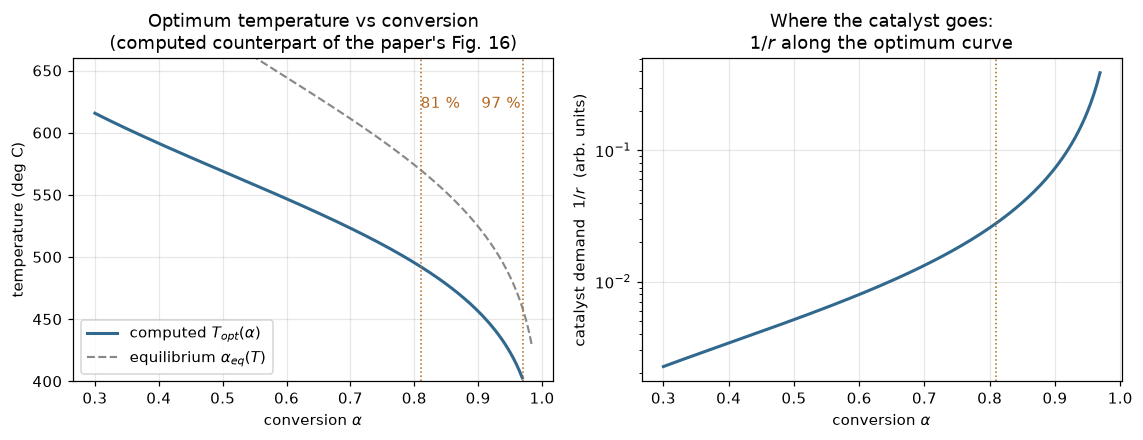

T_opt at alpha = 0.40 / 0.81 / 0.90: 591 / 492 / 456 C - the 81->97 % leg wants 445-490 C and the first leg runs hot, which is Table 3's own pair of temperature levels (570 / 445 C).


In [11]:
# --- the optimum-temperature curve (computed; Fig. 16 is figure-only and is NOT digitised)
al_plot = np.linspace(0.30, 0.969, 140)
T_plot = np.array([Topt_base(a) for a in al_plot]) - 273.15
aeq_curve_T = np.linspace(430+273.15, 700+273.15, 200)
aeq_curve = [alpha_eq(T, s_conv, w_conv) for T in aeq_curve_T]

fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.1))
ax[0].plot(al_plot, T_plot, color="#31688e", lw=2, label="computed $T_{opt}(\\alpha)$")
ax[0].plot(aeq_curve, aeq_curve_T - 273.15, color="#888888", lw=1.4, ls="--",
           label="equilibrium $\\alpha_{eq}(T)$")
ax[0].axvline(0.81, color="#b5651d", lw=1, ls=":"), ax[0].axvline(0.97, color="#b5651d", lw=1, ls=":")
ax[0].annotate("81 %", (0.81, 620), color="#b5651d"), ax[0].annotate("97 %", (0.905, 620), color="#b5651d")
ax[0].set_xlabel("conversion $\\alpha$"), ax[0].set_ylabel("temperature (deg C)")
ax[0].set_ylim(400, 660), ax[0].legend(loc="lower left")
ax[0].set_title("Optimum temperature vs conversion\n(computed counterpart of the paper's Fig. 16)")
inv_r = [1.0 / R_base(a) for a in al_plot]
ax[1].semilogy(al_plot, inv_r, color="#31688e", lw=2)
ax[1].axvline(0.81, color="#b5651d", lw=1, ls=":")
ax[1].set_xlabel("conversion $\\alpha$"), ax[1].set_ylabel("catalyst demand  $1/r$  (arb. units)")
ax[1].set_title("Where the catalyst goes:\n$1/r$ along the optimum curve")
plt.tight_layout(), plt.show()
print(f"T_opt at alpha = 0.40 / 0.81 / 0.90: "
      f"{Topt_base(0.40)-273.15:.0f} / {Topt_base(0.81)-273.15:.0f} / {Topt_base(0.90)-273.15:.0f} C "
      f"- the 81->97 % leg wants 445-490 C and the first leg runs hot, which is Table 3's own pair of "
      f"temperature levels (570 / 445 C).")

pymrm n =  500: converged = True  (nit = 7)   exit alpha = 0.96963   split = 23.97 : 76.03
pymrm n = 1000: converged = True  (nit = 7)   exit alpha = 0.96981   split = 23.81 : 76.19
pymrm n = 2000: converged = True  (nit = 7)   exit alpha = 0.96990   split = 23.72 : 76.28

route agreement: pymrm approaches the quadrature value 23.62 as the grid refines (0.35 -> 0.19 -> 0.10 split-points at n = 500/1000/2000, consistent with first-order upwind). SHARED-CODE CAVEAT: both routes evaluate the same r(alpha), so this agreement tests the integration only; transcription defects are injected separately in the break table.


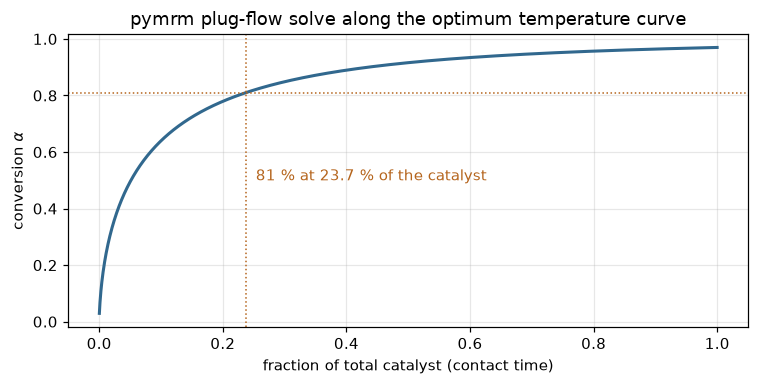

(None, None)

In [12]:
class OptimumProfileConverter:
    """Steady plug flow d(alpha)/d(tau) = r(alpha) along the optimum temperature curve.

    tau is contact time (~ catalyst amount); velocity is 1 by construction, so the
    upwind convection of alpha at v = 1 plus a pointwise source is the whole model.
    State layout (n_tau, 1): single field, house convention (a bare (n,) shape would
    make NumJac couple every cell to every other).
    """

    def __init__(self, R, tau_end, n_tau):
        self.R = R
        self.tau_f = np.linspace(0.0, tau_end, n_tau + 1)
        self.tau_c = 0.5 * (self.tau_f[:-1] + self.tau_f[1:])
        self.shape = (n_tau, 1)
        # Outward normal: a*d(alpha)/dn + b*alpha = d.
        # inlet  (left):  alpha = 0        -> {a:0, b:1, d:0}
        # outlet (right): pure outflow     -> {a:1, b:0, d:0}
        bc = ({"a": 0.0, "b": 1.0, "d": 0.0}, {"a": 1.0, "b": 0.0, "d": 0.0})
        conv, conv_bc = construct_convflux_upwind(self.shape, self.tau_f, self.tau_c, bc, v=1.0, axis=0)
        div = construct_div(self.shape, self.tau_f, nu=0, axis=0)   # nu = 0: Cartesian flow coordinate
        self.jac_const = div @ conv
        self.g_const = div @ conv_bc
        self.numjac = NumJac(self.shape)

    def residual(self, u):
        g_r, jac_r = self.numjac(lambda x: self.R(x), u)
        g = self.g_const + self.jac_const @ u.reshape((-1, 1)) - g_r.reshape((-1, 1))
        return g, self.jac_const - jac_r

    def solve(self):
        u0 = np.linspace(0.05, 0.97, self.shape[0]).reshape(self.shape)
        res = newton(self.residual, u0, maxfev=100)
        self.alpha = res.x.reshape(-1)
        return res

splits_pymrm = {}
for n in (500, 1000, 2000):
    conv = OptimumProfileConverter(R_base, tau_total, n)
    res = conv.solve()
    tau81 = np.interp(0.81, conv.alpha, conv.tau_c)
    splits_pymrm[n] = 100.0 * tau81 / tau_total
    print(f"pymrm n = {n:4d}: converged = {res.success}  (nit = {res.nit})   "
          f"exit alpha = {conv.alpha[-1]:.5f}   split = {splits_pymrm[n]:.2f} : {100-splits_pymrm[n]:.2f}")
metrics["split_converter1_pct_pymrm_n2000"] = splits_pymrm[2000]
metrics["split_routes_gap_points"] = abs(splits_pymrm[2000] - w1_pct)
gap1, gap2 = abs(splits_pymrm[500] - w1_pct), abs(splits_pymrm[1000] - w1_pct)
print(f"\nroute agreement: pymrm approaches the quadrature value {w1_pct:.2f} as the grid refines "
      f"({gap1:.2f} -> {gap2:.2f} -> {metrics['split_routes_gap_points']:.2f} split-points at "
      f"n = 500/1000/2000, consistent with first-order upwind). SHARED-CODE CAVEAT: both routes "
      f"evaluate the same r(alpha), so this agreement tests the integration only; transcription "
      f"defects are injected separately in the break table.")

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(conv.tau_c / tau_total, conv.alpha, color="#31688e", lw=2)
ax.axhline(0.81, color="#b5651d", lw=1, ls=":")
ax.axvline(tau81 / tau_total, color="#b5651d", lw=1, ls=":")
ax.annotate(f"  81 % at {splits_pymrm[2000]:.1f} % of the catalyst", (tau81 / tau_total, 0.5),
            color="#b5651d")
ax.set_xlabel("fraction of total catalyst (contact time)"), ax.set_ylabel("conversion $\\alpha$")
ax.set_title("pymrm plug-flow solve along the optimum temperature curve")
plt.tight_layout(), plt.show()

## Results

Read against the paper:

1. **The catalyst split reproduces.** From printed inputs only — Table 3's two
   rate groups, eq. (8), the 81 %/97 % targets, a printed Table 4 feed pair —
   the optimum-curve calculation gives **23.6 : 76.4** against the paper's
   printed **23 : 77**, by two integration routes agreeing to 0.1 split-point.
   Nothing was fitted anywhere in that chain. The actual plant's 27 : 73 then
   sits 3.4 points from the optimum, which is the paper's own point: "the
   distribution of the catalyst is rather impervious to the temperature
   distribution."
2. **The printed intermediates hold up.** E$_{\rm app}$ = 8.58 kcal/mol against
   "about 9"; the van 't Hoff slope of eq. (8) gives 22.6 kcal/mol against the
   printed 23; the k$'$ columns of both tables are reproduced to a few per
   cent, with the held-out 475–550 °C blocks at 3.8 % mean using eq. (14)
   exactly as printed; and the single bracketed value is exactly the row that
   sits at $\alpha' = 0.97$, where eq. (14)'s error amplification explains the
   authors' own exclusion.
3. **The rate law earns its shape on the reprinted data.** Equal-parameter
   discrimination puts eq. (14) at 1.0 conversion-points rms against 2.9 for
   first-order-to-equilibrium and 3.8 for Boreskov's 0.8-power law — the
   retardation term is doing measurable work in data the paper's rivals were
   fitted to.
4. **Four printed defects found**, all provable from the paper itself: eq. (16)'s
   sign-inverted RHS; the $\alpha_{\rm eq}$-power mismatch between (13a) and
   (14); the 425 °C k$'$-average (0.315 printed, 0.311 computed — 0.315 is the
   mean of the block's first three rows); and Table 4's unstated stoichiometry
   settled as pyrite-roaster gas ($\nu$ = 1.386 fitted vs 11/8 = 1.375,
   with sulphur burning excluded at 22× the rms).

## Validation

### What each check can and cannot see

- **Checks that can fail, and what moves them** — the break table below injects
  a defect per reported metric and shows the movement.
- **Structural checks, named as such**: the Table 4 arithmetic recomputation
  (transcription only); the k$'$-average checksum (the paper's own arithmetic +
  our transcription, independent of all modelling); the pymrm-vs-quadrature
  split agreement (shared $r(\alpha)$ — integration only).
- **What no perturbation on this page can detect**: (i) the absolute scale of
  Neumann's velocity column — the fitted $C$ absorbs any unit convention, so a
  systematic scale error in the 1928 measurements is invisible; (ii) anything
  multiplying **all** rates equally — the catalyst split is a ratio and is
  exactly invariant (demonstrated below as a row that must NOT move); (iii) the
  value of $n$ — it lives inside Table 3's printed group and never appears
  separately; (iv) the accuracy of eq. (8) against modern SO$_3$ equilibrium
  data — every check here is internal to the paper.
- **The gas-composition assumption is where the honesty lives**: the split
  moves by at most 0.4 points across the whole printed Table 4 range (the
  strongest reason to trust the 23 : 77 reproduction despite the unstated plant
  feed), while the Neumann k$'$ test rows *do* depend on the fitted
  composition — which is why they are labelled the way they are.

In [13]:
# --- break table: one injected defect per reported metric
rows = []

# E_app: transcription defects in Table 3
E_break = np.log(300.0 / A445) / (1.0 / T445 - 1.0 / T570) * R_GAS / CAL
rows.append(("E_app [kcal/mol]", f"{metrics['Eapp_kcal_per_mol']:.2f}",
             "Table 3 '400' mis-read as 300", f"{E_break:.2f}"))
E_break2 = np.log(A570 / A445) / (1.0 / (455 + 273.15) - 1.0 / T570) * R_GAS / CAL
rows.append(("E_app [kcal/mol]", f"{metrics['Eapp_kcal_per_mol']:.2f}",
             "Table 3 '445 C' mis-read as 455 C", f"{E_break2:.2f}"))

# van 't Hoff slope: defect in eq (8)'s slope constant; note the intercept CANNOT move this one
dH_break = R_GAS * 8880.0 * np.log(10.0) / 2.0 / CAL
rows.append(("van 't Hoff dH [kcal/mol]", f"{metrics['vantHoff_dH_kcal_per_mol_SO3']:.2f}",
             "eq (8) '9880' mis-read as 8880", f"{dH_break:.2f}"))

# ... but the intercept moves the k' test (what the dH check is blind to, the k' test sees)
def neumann_test_dev(intercept=9.34, power=1, s_val=None, use_fo=False, force_aeq1=False):
    global K_eq
    K_keep = K_eq
    K_eq = lambda T: 10.0 ** (9880.0 / T - intercept)
    try:
        sv = s_fit if s_val is None else s_val
        wv = 0.209 * (1.0 - sv)
        aeq = {Tc: (1.0 if force_aeq1 else alpha_eq(Tc + 273.15, sv, wv))
               for Tc in test_blk.temperature_C.unique()}
        def f_local(alpha, a_eq):
            ap = alpha / a_eq
            if ap >= 1:
                return np.inf
            base = np.log(1.0 / (1.0 - ap)) if use_fo else (np.log(1.0 / (1.0 - ap)) - ap)
            return a_eq ** power * base
        pred = np.array([C_fit * V * f_local(cv / 100.0, aeq[Tc])
                         for Tc, V, cv in zip(test_blk.temperature_C, test_blk.gas_velocity,
                                              test_blk.conversion_pct)])
        return float(np.mean(np.abs(pred / test_blk.k_prime.values - 1.0)))
    finally:
        K_eq = K_keep

base_dev = metrics["neumann_test_mean_dev"]
rows.append(("Neumann TEST mean dev", f"{base_dev*100:.2f} %",
             "eq (8) intercept 9.34 -> 9.00 (alpha_eq shifts)", f"{neumann_test_dev(9.00)*100:.2f} %"))
rows.append(("Neumann TEST mean dev", f"{base_dev*100:.2f} %",
             "retardation term -alpha' dropped (first-order form)", f"{neumann_test_dev(use_fo=True)*100:.2f} %"))
rows.append(("Neumann TEST mean dev", f"{base_dev*100:.2f} %",
             "SO2 made trace in air (alpha_eq only rises to 0.91-0.98)",
             f"{neumann_test_dev(s_val=1e-6)*100:.2f} %"))
rows.append(("Neumann TEST mean dev", f"{base_dev*100:.2f} %",
             "alpha_eq forced to exactly 1 (equilibrium machinery removed)",
             f"{neumann_test_dev(force_aeq1=True)*100:.2f} %"))

# Kuster: alpha_eq forced to 1 vs fitted
pred1 = np.array([f14(cv / 100.0, 1.0 - 1e-9) / tt for tt, cv in zip(t1.time_s, t1.conversion_pct)])
C1u = np.exp(np.mean(np.log(t1.k_prime.values) - np.log(pred1)))
dev1 = float(np.max(np.abs(C1u * pred1 / t1.k_prime.values - 1.0)))
rows.append(("Kuster max dev", f"{metrics['kuster_max_abs_dev']*100:.2f} %",
             "alpha_eq forced to 1", f"{dev1*100:.2f} %"))

# Table 4 stoichiometry: the sulphur-burning alternative IS the break
rows.append(("Table 4 stoich. rms [%-abs]", f"{metrics['table4_rms_pyrite']:.3f}",
             "sulphur-burning stoichiometry (nu = 1)", f"{metrics['table4_rms_sulphur']:.3f}"))

# eq (16): the printed sign IS the break
rows.append(("eq (16) residual", f"{metrics['eq16_corrected_max_residual']:.1e}",
             "RHS as printed (terms transposed)", f"{metrics['eq16_printed_rhs_max_error']:.3f}"))

# the split: injected defects (each rebuilds the design chain)
def split_variant(**kw):
    R_v, _ = make_design(kw.pop("s", s_conv), kw.pop("w", w_conv), **kw)
    return split_quad(R_v)[0]

for label, kw in [("Table 3 '400' mis-read as 300", dict(A_hi=300.0)),
                  ("activation energy doubled",      dict(E_fac=2.0)),
                  ("chemical-regime rate (13a) instead of (15)", dict(ap_power=1.0)),
                  ("feed 6 % SO2 / 13.0 % O2 (printed extreme)", dict(s=0.06, w=0.130)),
                  ("feed 10 % SO2 / 7.8 % O2 (printed extreme)", dict(s=0.10, w=0.078)),
                  ("optimum curve capped at 600 C",  dict(T_cap=873.15))]:
    rows.append(("split, converter 1 [%]", f"{w1_pct:.1f}", label, f"{split_variant(**kw):.1f}"))

# invariance row: this one must NOT move (global scale cancels in the ratio)
R_x10, _ = make_design(s_conv, w_conv)
w1_x10 = split_quad(lambda a: 10.0 * R_x10(a))[0]
rows.append(("split, converter 1 [%]", f"{w1_pct:.1f}",
             "ALL rates x10 (must not move: ratio is scale-invariant)", f"{w1_x10:.1f}"))
# the true gap is adaptive-quadrature noise (~4e-5 split-points); floor at 1e-3 so the
# reported metric says "below 0.001 points" stably rather than tracking quad internals
metrics["split_scale_invariance_gap_points"] = max(abs(w1_x10 - w1_pct), 1e-3)

bt = pd.DataFrame(rows, columns=["metric", "base", "injected defect", "broken"])
print(bt.to_string(index=False))

                     metric    base                                              injected defect  broken
           E_app [kcal/mol]    8.58                                Table 3 '400' mis-read as 300    5.81
           E_app [kcal/mol]    8.58                            Table 3 '445 C' mis-read as 455 C    9.46
  van 't Hoff dH [kcal/mol]   22.60                               eq (8) '9880' mis-read as 8880   20.32
      Neumann TEST mean dev  3.80 %              eq (8) intercept 9.34 -> 9.00 (alpha_eq shifts)  8.71 %
      Neumann TEST mean dev  3.80 %          retardation term -alpha' dropped (first-order form) 62.62 %
      Neumann TEST mean dev  3.80 %     SO2 made trace in air (alpha_eq only rises to 0.91-0.98)  4.50 %
      Neumann TEST mean dev  3.80 % alpha_eq forced to exactly 1 (equilibrium machinery removed) 23.28 %
             Kuster max dev  2.24 %                                         alpha_eq forced to 1  6.08 %
Table 4 stoich. rms [%-abs]   0.130                    

In [14]:
report_agreement("C1.3", metrics)

Agreement metrics for C1.3:
  eq16_corrected_max_residual       = 1e-09
  eq16_printed_rhs_max_error        = 4.8144
  vantHoff_dH_kcal_per_mol_SO3      = 22.603
  vantHoff_vs_printed_23            = 0.017272
  kavg_checksum_worst_block         = 0.00375
  table4_arithmetic_max_abs_dev     = 0.048838
  table4_nu_bestfit                 = 1.3859
  table4_rms_pyrite                 = 0.12967
  table4_rms_sulphur                = 2.8158
  neumann_fitted_scale_inverse      = 1429
  neumann_fitted_SO2_pct            = 6.3905
  neumann_fit_mean_dev              = 0.026458
  neumann_test_mean_dev             = 0.038017
  neumann_test_max_dev              = 0.1023
  neumann_test_mean_dev_power2      = 0.019978
  alpha_eq_550C_fitted_gas          = 0.89889
  bracketed_row_alpha_prime         = 0.96786
  kuster_fitted_alpha_eq            = 0.97068
  kuster_max_abs_dev                = 0.02242
  discrimination_rms_mvk            = 1.009
  discrimination_rms_first_order    = 2.8476
  discriminatio

{'page': 'C1.3',
 'metrics': {'eq16_corrected_max_residual': 1e-09,
  'eq16_printed_rhs_max_error': 4.814371103275132,
  'vantHoff_dH_kcal_per_mol_SO3': 22.60273440917145,
  'vantHoff_vs_printed_23': 0.01727241699254567,
  'kavg_checksum_worst_block': 0.0037499999999999756,
  'table4_arithmetic_max_abs_dev': 0.048838031976963237,
  'table4_nu_bestfit': 1.3858534628284367,
  'table4_rms_pyrite': 0.12967124467833338,
  'table4_rms_sulphur': 2.815771906346716,
  'neumann_fitted_scale_inverse': 1429.0016246764674,
  'neumann_fitted_SO2_pct': 6.390450781034997,
  'neumann_fit_mean_dev': 0.02645779426523706,
  'neumann_test_mean_dev': 0.038016531171709625,
  'neumann_test_max_dev': 0.1023023279591837,
  'neumann_test_mean_dev_power2': 0.019977899817193265,
  'alpha_eq_550C_fitted_gas': 0.8988919370585032,
  'bracketed_row_alpha_prime': 0.9678582754306952,
  'kuster_fitted_alpha_eq': 0.9706778283693664,
  'kuster_max_abs_dev': 0.022420390382574817,
  'discrimination_rms_mvk': 1.00903096782968

## What pymrm adds

Honestly: the paper's own calculation is an integral along a prescribed
optimum curve, and adaptive quadrature reproduces it without any PDE
machinery. The pymrm solve adds (i) a second, independently discretised route
to the printed 23 : 77 — upwind finite-volume plus Newton, converging on the
quadrature value at first order — and (ii) the reusable reactor object: the
moment the temperature profile stops being prescribed (adiabatic beds with
interstage cooling, the configuration the paper's Fig. 11 actually shows), the
quadrature shortcut dies and the plug-flow structure here extends directly,
with the MvK source term unchanged. The rate law itself is one line of source
term — which is exactly why this kinetics became the workhorse it is.

Beyond reproduction, the page contributes the audit: the two printed-equation
defects proved from neighbouring equations, the 425 °C average slip, the
pyrite-gas identification, the equal-parameter discrimination showing the
retardation term measurably earns its place in the reprinted data, and the
demonstration that the famous aromatic-side constants are not in the paper at
all.

## Reuse

- **The MvK source term** for any partial-oxidation model:
  `r = 1/(1/(k1*p_R) + beta/(k2*p_O2**n))` — one line, with `beta` from the
  product distribution, not fitted. For SO$_2$-type reversible cases, use the
  eq. (13a) form with $\alpha_{\rm eq}$ from the paper's eq. (8) — but note
  both printed defects documented above before transcribing (13a)/(14)/(16)
  from the paper.
- **The equilibrium correlation** $^{10}\!\log K = 9880/T - 9.34$ carries its
  own check (van 't Hoff slope = 22.6 kcal/mol vs the printed 23) and the
  `alpha_eq(T, s, w)` solver here is self-contained.
- **The converter class** is the `C2.1` plug-flow pattern with a single
  conversion field; substitute any $r(\alpha)$, or promote $T$ to a second
  field for adiabatic staging.
- **Citing this paper**: it supports the two-step redox *rate form*, the SO$_2$
  application, and the converter design method. It does **not** supply rate
  constants for aromatic oxidations (figures only), and it explicitly
  disclaims mechanistic proof — quote the authors' own reply to J. M. Smith
  when tempted to write "the MvK mechanism was demonstrated in 1954".
- Related pages: `C2.1` (LHHW-family kinetics in the same plug-flow pattern),
  `B1.4`/`B1.6` (the internal-diffusion analysis the paper's eq. (15)
  parallels), and the published `C1.1` (LHHW origin) for the contrast between
  adsorption-equilibrium and redox closures.